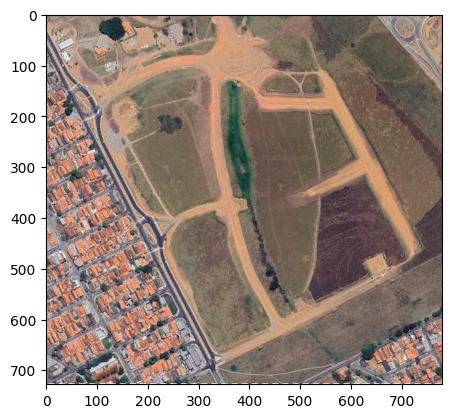

In [3]:
# A simple example that uses a perceptron to classify
# image data
#
# Author: Fabrício Galende Marques de Carvalho

from random import shuffle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# load image from file
data_path = "./sample_data/"
file_name = "sample_bare_soil.bmp"
img = mpimg.imread(data_path + file_name)

# display the image
plt.imshow(img)

[207 183 159 255]


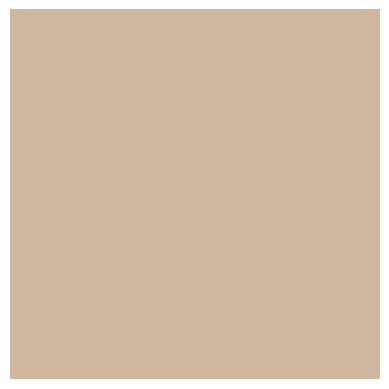

[105  87  73 255]


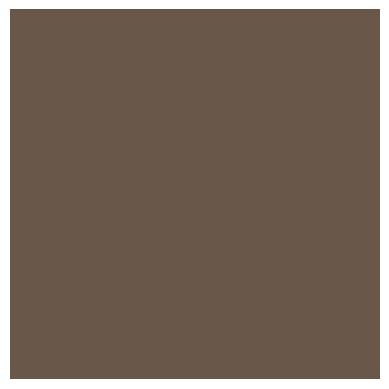

In [47]:
# Take image samples to perform neural network training:

# First, let`s examine a positive and a negative example:
# positive
x = 360
y = 120
print(img[x,y])
pixel = np.array([[img[x,y]]], dtype=np.uint8)

plt.imshow(pixel)
plt.axis('off')
plt.show()

#negative
x = 231
y = 450
print(img[x,y])
pixel = np.array([[img[x,y]]], dtype=np.uint8)

plt.imshow(pixel)
plt.axis('off')
plt.show()

In [70]:
# get sample coordinates:
positive_examples_coords = [(360, 120), (586, 160), (620, 310)]
negative_examples_coords = [(298, 310), (450, 700), (650, 650)]
p_n_examples = positive_examples_coords + negative_examples_coords
points = []
classes = []
for i, v in enumerate( p_n_examples ):
    points.append(img[v[0],v[1]][0:3])
    if i < len(p_n_examples)/2:
        classes.append([1])
    else:
        classes.append([0])


print(points)
print(classes)

[array([207, 183, 159], dtype=uint8), array([149, 120, 112], dtype=uint8), array([172, 146, 129], dtype=uint8), array([161, 133, 120], dtype=uint8), array([124, 112,  96], dtype=uint8), array([76, 98, 95], dtype=uint8)]
[[1], [1], [1], [0], [0], [0]]


In [86]:
# Build a new input considering bias:
new_input = []
bias = 1
for x_in in points:
    new_input.append(np.concatenate((x_in, np.array([int(bias)]))))
print(new_input)

[array([207, 183, 159,   1]), array([149, 120, 112,   1]), array([172, 146, 129,   1]), array([161, 133, 120,   1]), array([124, 112,  96,   1]), array([76, 98, 95,  1])]


In [87]:
# now we import, configure and initialized our perceptron
import numpy as np


class ActivationFunction:

    def __init__(self, act_function):
        self.act_function = act_function

    def activate(self,v):
        return self.act_function(v)


class Perceptron:

    def __init__(self, act_function, n_inputs, n_outputs):
        self.act_function = act_function
        self.n_inputs = n_inputs  # no bias is taken into account
        self.n_outputs = n_outputs
        self.synaptic_weights = np.random.rand(n_outputs, n_inputs)

    def output(self, inputs):
        v = np.dot(self.synaptic_weights, np.array(inputs))
        y_e = list( map(self.act_function.activate, v) )
        return y_e

    def learn(self, y_t, y_e, x, alpha):
        for i in range(self.n_outputs):
            for j in range(self.n_inputs):
                error = y_t[i] - y_e[i]
                self.synaptic_weights[i,j] = self.synaptic_weights[i,j] + alpha * error * x[j]

# configure the activation function:
def my_activation_function(v):
    return (1/(1+np.exp(-v)))

# freeze random number generator seed to get the same result
np.random.seed(120)
# build a perceptron instance that uses this activation function.
my_act_function = ActivationFunction(my_activation_function)
my_perceptron = Perceptron(my_act_function, 4, 1)
print(my_perceptron.synaptic_weights)

[[0.67795555 0.5129588  0.62370571 0.47714247]]


/tmp/ipykernel_8851/413255124.py:35: RuntimeWarning: overflow encountered in exp
  return (1/(1+np.exp(-v)))


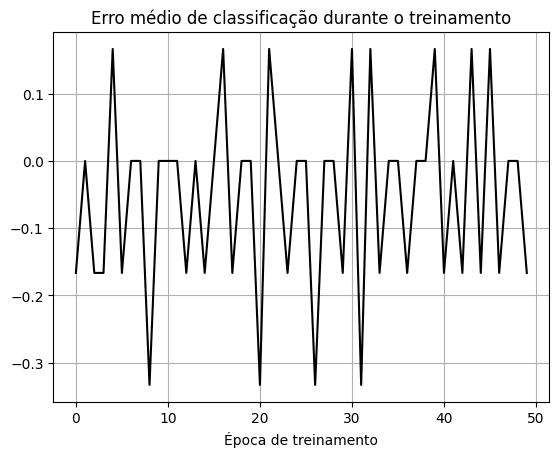

In [91]:
# Now we train our perceptron

learning_rate = 0.02
n_epochs = 50
e_epoch = [] #to store the classification error in each epoch (average)
w_0_epoch = []
indices = list(range(len(classes)))
e_instantaneous = []
for epoch in range(n_epochs): # for each epoch
    e_point = []
    shuffle(indices)
    for k in indices:    #for each input/output pair
        y_e = my_perceptron.output(new_input[k])
        e_point.append(classes[k][0] - y_e[0])
        e_instantaneous.append(classes[k][0] - y_e[0])
        my_perceptron.learn(classes[k], y_e, new_input[k], learning_rate)
    e_epoch.append( np.mean(e_point) )
    w_0_epoch.append(my_perceptron.synaptic_weights[0][0])

plt.plot(e_epoch, color="black")
plt.title("Erro médio de classificação durante o treinamento")
plt.xlabel("Época de treinamento")
plt.grid()

/tmp/ipykernel_8851/413255124.py:35: RuntimeWarning: overflow encountered in exp
  return (1/(1+np.exp(-v)))


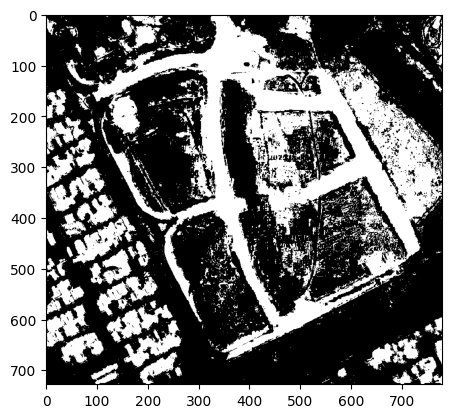

In [92]:
# Now we try to classify image regions:

n_rows = len(img)
n_cols = len(img[0])
classified_img = np.zeros((n_rows, n_cols, 3), dtype=np.uint8)  # n_rows x n_cols RGB
for x in range(n_rows):
    for y in range(n_cols):
        nn_input =  np.concatenate( ( img[x,y][0:3], np.array([int(bias)])))
        y_e = my_perceptron.output(nn_input)
        if y_e[0]  > 0.90:
            classified_img[x,y] = [255, 255, 255]
        else:
            classified_img[x,y] = [0, 0, 0]

plt.imshow(classified_img)